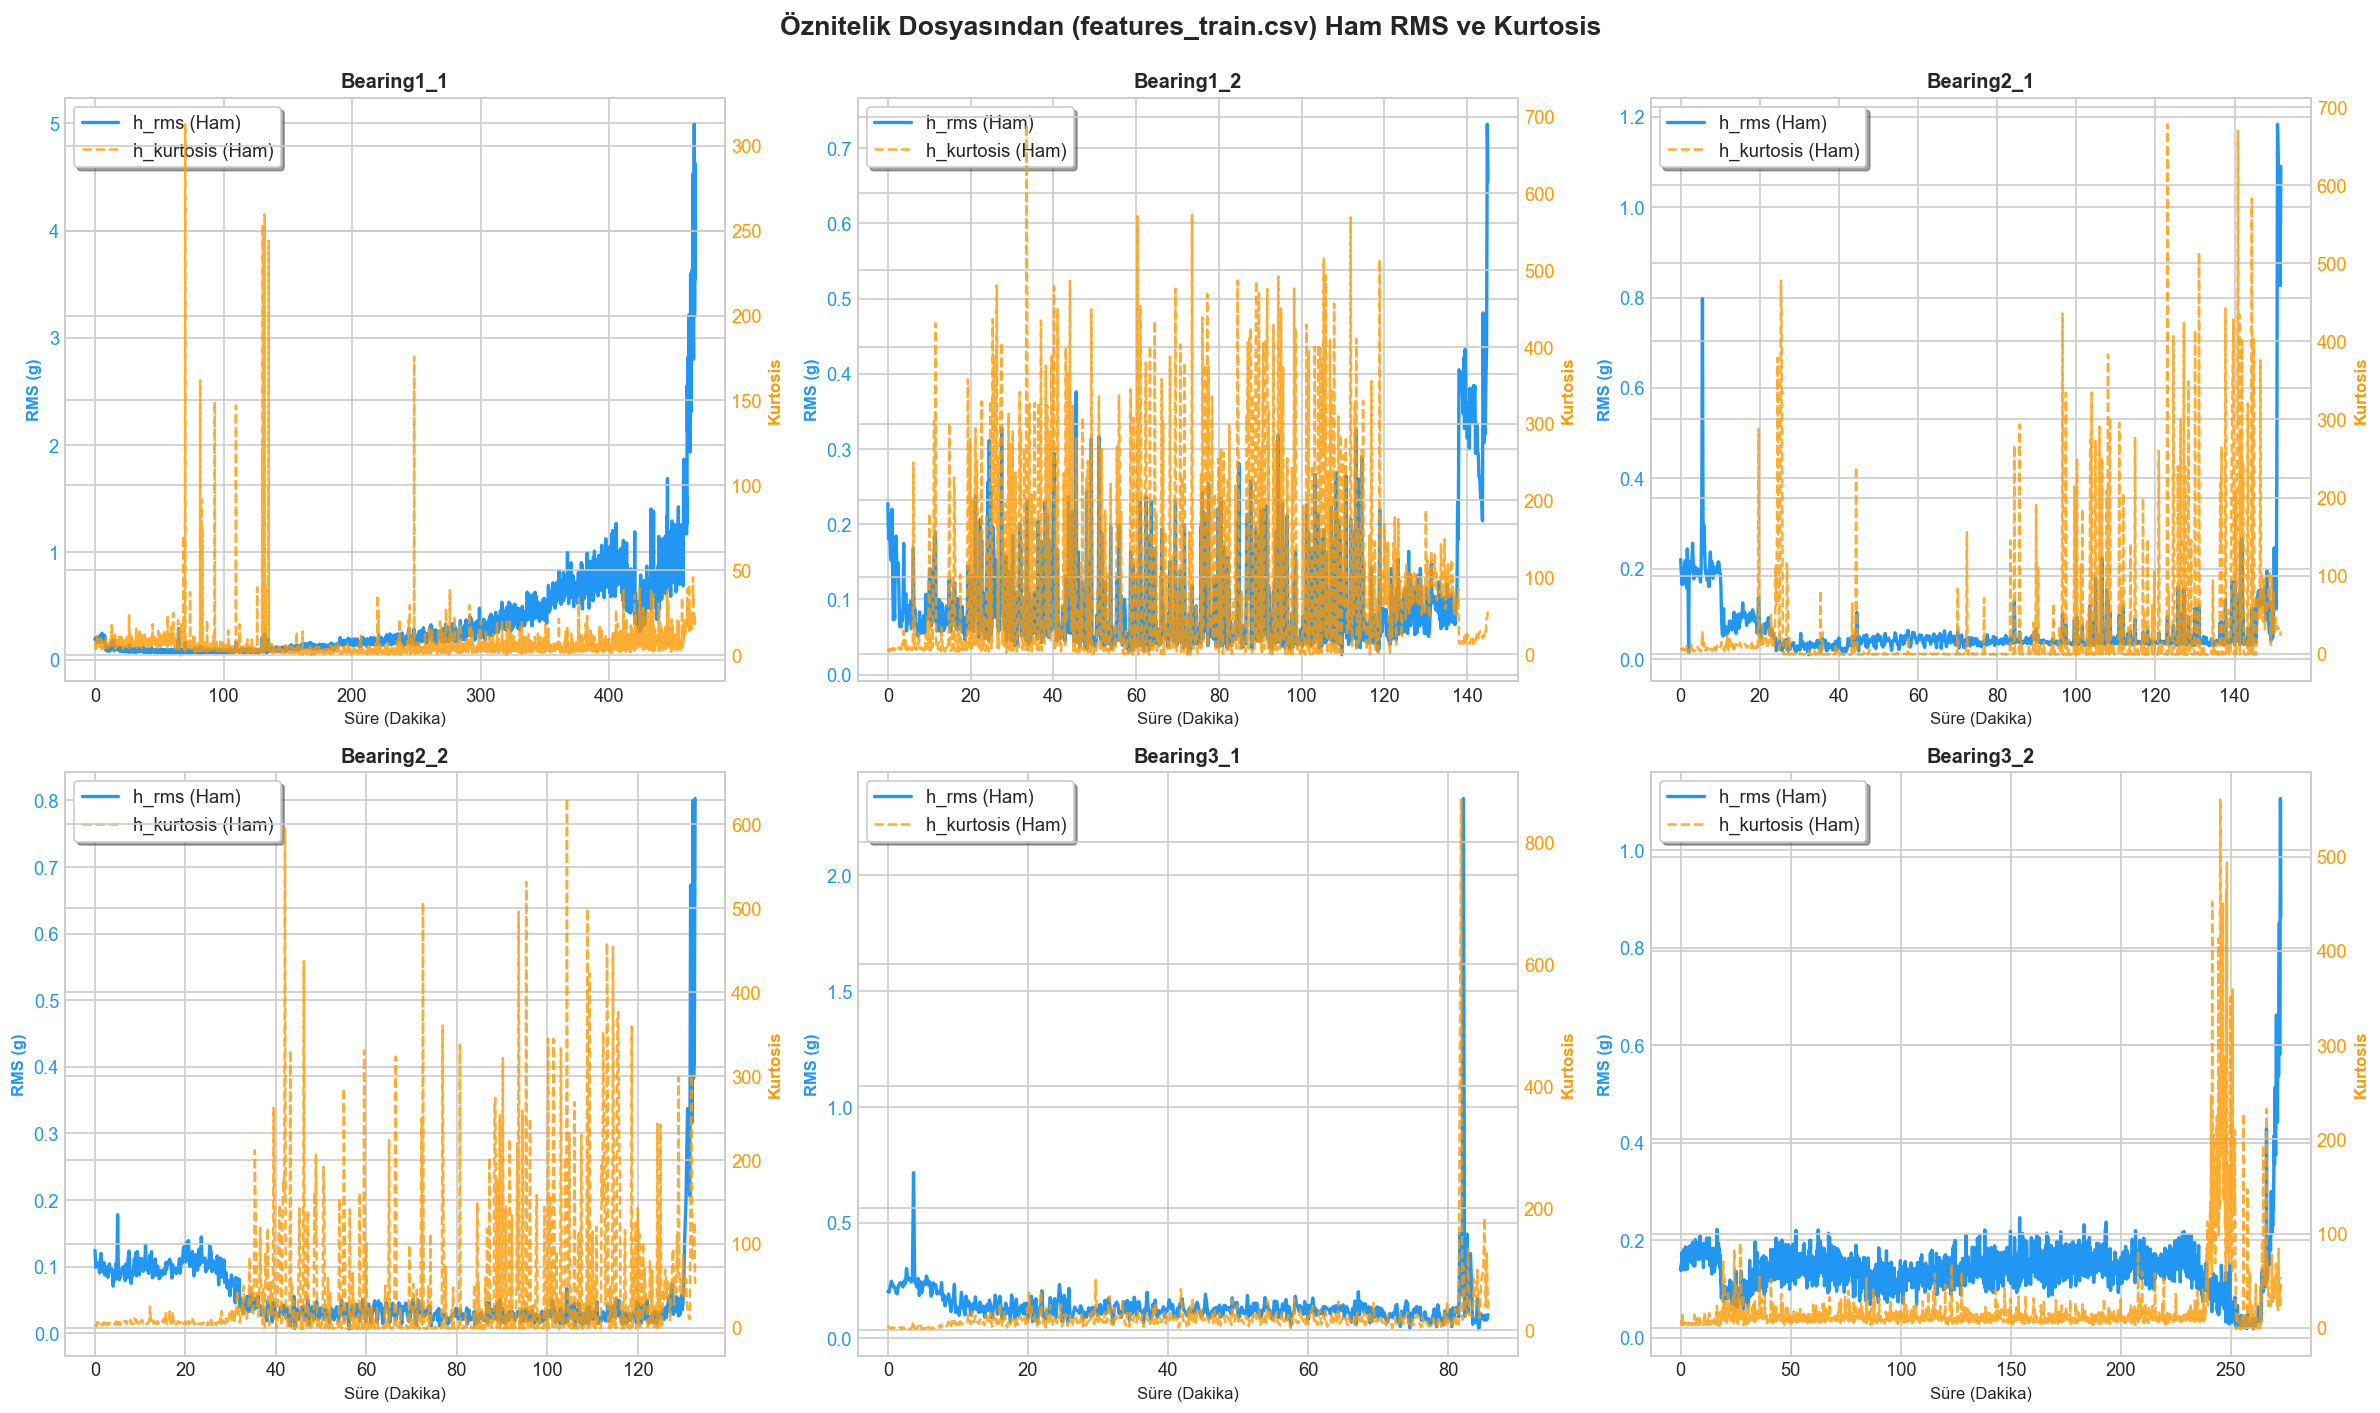

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daha önce başarıyla kaydettiğin CSV dosyasının yolu
# Eğer farklı bir yere kaydettiysen burayı güncelleyebilirsin.
features_path = r"C:\Users\asus\OneDrive\Masaüstü\femto_rul\data\processed\features_train.csv"

# Veriyi oku (Binlerce dosyayı okumak yerine tek bir CSV, saniyeler sürer)
df = pd.read_csv(features_path)

# Sadece Learning set rulmanları
bearings = ["Bearing1_1", "Bearing1_2", "Bearing2_1", "Bearing2_2", "Bearing3_1", "Bearing3_2"]

# Çizim Ayarları
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Öznitelik Dosyasından (features_train.csv) Ham RMS ve Kurtosis', fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

for i, bname in enumerate(bearings):
    ax1 = axes[i]
    
    # O rulmana ait satırları çek
    b_df = df[df['bearing'] == bname].copy()
    
    if b_df.empty:
        ax1.set_title(f"{bname} (Veri Yok)")
        continue
        
    # X ekseni: time_s sütununu dakikaya çevir
    times_min = b_df['time_s'] / 60.0
    
    # Y eksenleri: extract_features fonksiyonunda ürettiğin saf sütunlar
    rms_raw = b_df['h_rms']
    kurt_raw = b_df['h_kurtosis']
    
    ax2 = ax1.twinx()  
    
    line1 = ax1.plot(times_min, rms_raw, color='#2196F3', linewidth=2, label='h_rms (Ham)')[0]
    line2 = ax2.plot(times_min, kurt_raw, color='#FF9800', linewidth=1.5, linestyle='--', alpha=0.8, label='h_kurtosis (Ham)')[0]
    
    ax1.set_title(f"{bname}", fontsize=12, fontweight='bold')
    ax1.set_xlabel('Süre (Dakika)', fontsize=10)
    ax1.set_ylabel('RMS (g)', color='#2196F3', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Kurtosis', color='#FF9800', fontsize=10, fontweight='bold')
    
    ax1.tick_params(axis='y', labelcolor='#2196F3')
    ax2.tick_params(axis='y', labelcolor='#FF9800')
    
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(top=0.92) 
plt.show()